## Task 2: Data cleaning and preprocessing
- Description cleean and preprocess a raw dataset to make it suitable for analysis.

### Objectives:
- Handle missing data (e.g., imputation, removal).
- Detect and remove outliers.
- Convert categorical variables into numerical format
- using one-hot encoding or label encoding.
- Normalize or standardize numerical data.
- Tools: Python, pandas, scikit-learn

#### import required  libraries and load the data

In [17]:
# import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


In [18]:
# Data loading 
data = pd.read_csv("cleaned_data.csv")

#### Data understanding

In [19]:
# data understanding
# top 10 rows
data.head(10)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,sqft_above,sqft_basement,yearBuilt,year_renovated,street,city,statezip,country
0,2014-05-09 00:00:00,376000.0,3,2.00,1340,1384,3.0,3,1340,0,2008,0,9245-9249 Fremont Ave N,Seattle,WA 98103,USA
1,2014-05-09 00:00:00,800000.0,4,3.25,3540,159430,2.0,3,3540,0,2007,0,33001 NE 24th St,Carnation,WA 98014,USA
2,2014-05-09 00:00:00,2238888.0,5,6.50,7270,130017,2.0,3,6420,850,2010,0,7070 270th Pl SE,Issaquah,WA 98029,USA
3,2014-05-09 00:00:00,324000.0,3,2.25,998,904,2.0,3,798,200,2007,0,820 NW 95th St,Seattle,WA 98117,USA
4,2014-05-10 00:00:00,549900.0,5,2.75,3060,7015,1.0,5,1600,1460,1979,0,10834 31st Ave SW,Seattle,WA 98146,USA
5,2014-05-10 00:00:00,320000.0,3,2.50,2130,6969,2.0,3,2130,0,2003,0,Cedar to Green River Trail,Maple Valley,WA 98038,USA
6,2014-05-10 00:00:00,875000.0,4,2.00,2520,6000,1.0,3,1400,1120,1921,2007,6521 Fremont Ave N,Seattle,WA 98103,USA
7,2014-05-10 00:00:00,265000.0,4,1.00,1940,9533,1.0,3,1080,860,1962,2003,9908 S 210th Pl,Kent,WA 98031,USA
8,2014-05-10 00:00:00,394950.0,3,2.50,1350,1250,3.0,3,1270,80,2006,0,5940 California Ave SW,Seattle,WA 98136,USA
9,2014-05-11 00:00:00,842500.0,4,2.50,2160,5298,2.5,4,2160,0,1902,0,906 17th Ave,Seattle,WA 98122,USA


In [20]:

# last 10 rows of the data 
data.tail()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,sqft_above,sqft_basement,yearBuilt,year_renovated,street,city,statezip,country
4135,2014-07-09 00:00:00,308166.666667,3,1.75,1510,6360,1.0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4136,2014-07-09 00:00:00,534333.333333,3,2.50,1460,7573,2.0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4137,2014-07-09 00:00:00,416904.166667,3,2.50,3010,7014,2.0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4138,2014-07-10 00:00:00,203400.000000,4,2.00,2090,6630,1.0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA
4139,2014-07-10 00:00:00,220600.000000,3,2.50,1490,8102,2.0,4,1490,0,1990,0,18717 SE 258th St,Covington,WA 98042,USA


In [34]:
# shape of the data
data.shape

(4140, 16)

In [ ]:
# check duplicates
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4135    False
4136    False
4137    False
4138    False
4139    False
Length: 4140, dtype: bool

In [ ]:
# check missing value
data.isna().any()

date              False
price             False
bedrooms          False
bathrooms         False
sqft_living       False
sqft_lot          False
floors            False
condition         False
sqft_above        False
sqft_basement     False
yearBuilt         False
year_renovated    False
street            False
city              False
statezip          False
country           False
dtype: bool

In [23]:
# check for null value
data.isnull().sum()

date              0
price             0
bedrooms          0
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
condition         0
sqft_above        0
sqft_basement     0
yearBuilt         0
year_renovated    0
street            0
city              0
statezip          0
country           0
dtype: int64

### feature selection and engineering

In [24]:
# print all columns
data.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'condition', 'sqft_above', 'sqft_basement', 'yearBuilt',
       'year_renovated', 'street', 'city', 'statezip', 'country'],
      dtype='str')

In [25]:
# features selections
features = data[[ 
    'price', 'bedrooms', 'bathrooms', 
    'sqft_lot',
       'floors',  
       'sqft_basement', 'yearBuilt',
       'year_renovated', 
       'city', 
       'country']]

In [26]:
# print the selected features
features.head()

,price,bedrooms,bathrooms,sqft_lot,floors,sqft_basement,yearBuilt,year_renovated,city,country
0,376000.0,3,2.00,1384,3.0,0,2008,0,Seattle,USA
1,800000.0,4,3.25,159430,2.0,0,2007,0,Carnation,USA
2,2238888.0,5,6.50,130017,2.0,850,2010,0,Issaquah,USA
3,324000.0,3,2.25,904,2.0,200,2007,0,Seattle,USA
4,549900.0,5,2.75,7015,1.0,1460,1979,0,Seattle,USA


In [33]:
# shape of the data
features.shape

(4140, 10)

#### feature engineering

In [27]:
# Rename some of the columns
features = features.rename(columns={
            'sqft_lot': 'lotSize',
            'sqft_basement': 'basement',
            'year_renovated': 'yearRenovated',
            'bathrooms': 'bathRooms',
            'bedrooms': 'bedRooms'
})

### Detect outliers and remove them

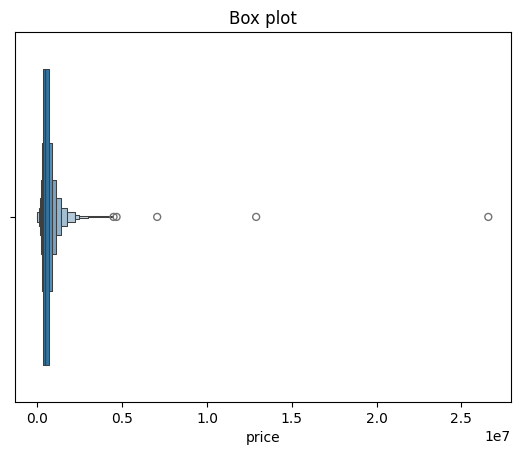

In [39]:
# visualization and detecting outlier after cleaning
sns.boxenplot(x=features['price'])
plt.title('Box plot')
plt.show()

In [37]:
# Detecting outlier using interquartile Range method
q1 = features['price'].quantile(0.25)
q3 = features['price'].quantile(0.75)

IQR =  q3 - q1

lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR

cleaned = features[(features['price']  >= lower) & (features['price'] <= upper)]


print("Original dataset:", features.shape)
print("Clean dataset:", cleaned.shape)

Original dataset: (4140, 10)
Clean dataset: (3925, 10)


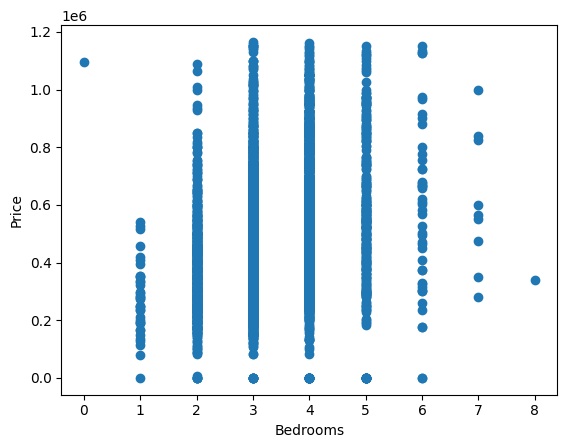

In [ ]:
# visualization after cleaning
plt.scatter(cleaned['bedRooms'], cleaned['price'])
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.show()

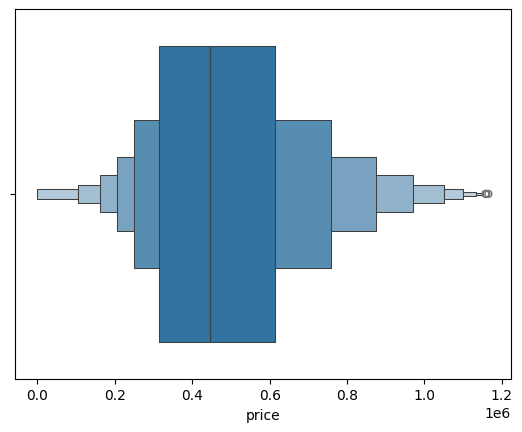

In [ ]:
# visual checking
sns.boxenplot(x=cleaned['price'])
plt.show()

### Convert categorical variables into numerical format

In [41]:
# Encoding categorical variables
encoder = LabelEncoder()
encoder.fit_transform(cleaned['city'])
encoder.fit_transform(cleaned['country'])

array([0, 0, 0, ..., 0, 0, 0], shape=(3925,))

### Normalize or standardize numerical data.

In [44]:
# Normalize or standardize numerical data.
scaler = StandardScaler()
cleaned[['bedRooms', 'bathRooms', 
         'lotSize', 'floors', 'basement',
       'yearBuilt', 'yearRenovated', #'city', 
       #'country'
       ]] = scaler.fit_transform(cleaned[['bedRooms', 'bathRooms', 
         'lotSize', 'floors', 'basement',
       'yearBuilt', 'yearRenovated', #'city', 
       #'country'
       ]])
print(cleaned.head())

      price  bedRooms  bathRooms   lotSize    floors  basement  yearBuilt  \
0  376000.0 -0.407038  -0.143346 -0.361260  2.815716 -0.670397   1.255990   
1  800000.0  0.722824   1.567825  3.997450  0.940960 -0.670397   1.222190   
3  324000.0 -0.407038   0.198888 -0.374498  0.940960 -0.203111   1.222190   
4  549900.0  1.852686   0.883357 -0.205964 -0.933795  2.740788   0.275797   
5  320000.0 -0.407038   0.541123 -0.207233  0.940960 -0.670397   1.086991   

   yearRenovated          city country  
0      -0.827295       Seattle     USA  
1      -0.827295     Carnation     USA  
3      -0.827295       Seattle     USA  
4      -0.827295       Seattle     USA  
5      -0.827295  Maple Valley     USA  


In [46]:
# save the clean house data
houseData = cleaned.to_csv("house_data.csv", index=False)


### Task 2 finished